
 Ojivas


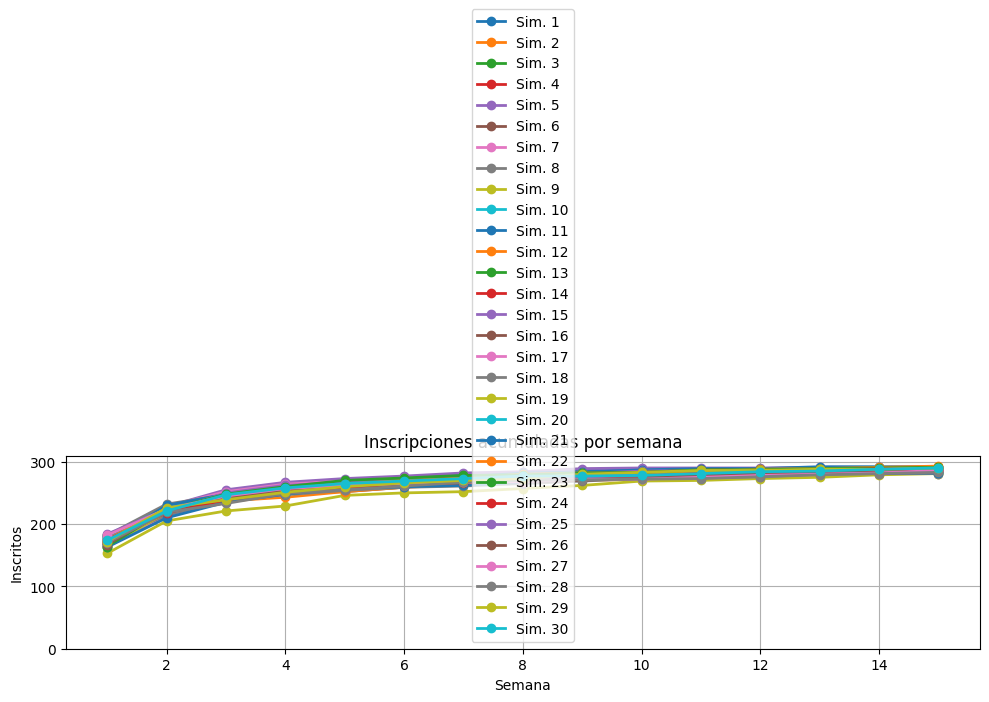

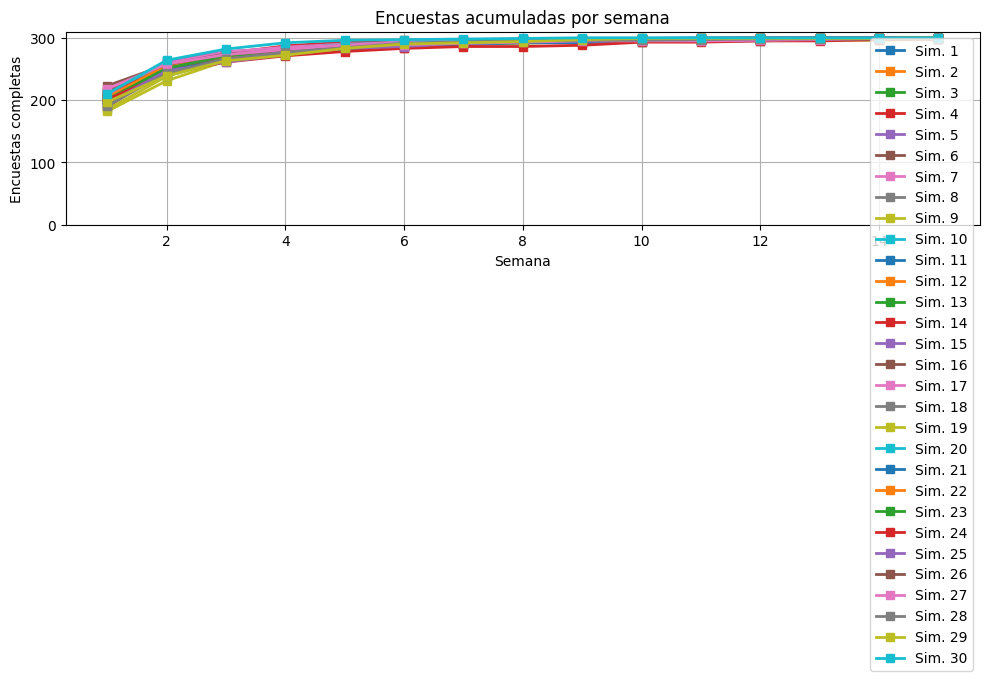


 Histograma inscritos


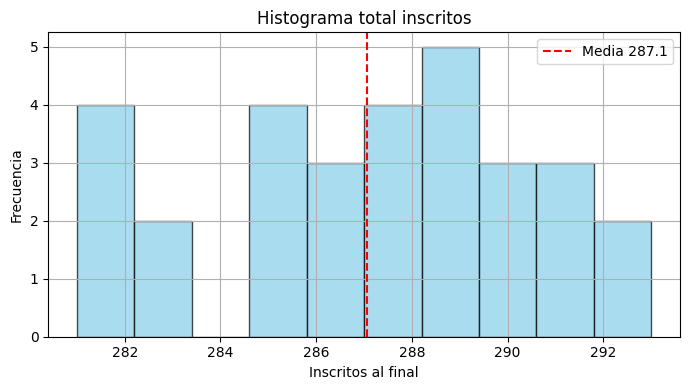


 Histograma encuestas


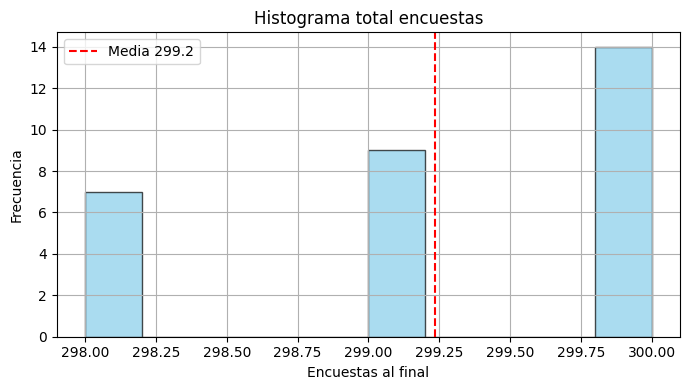


 Diagrama de dispersión


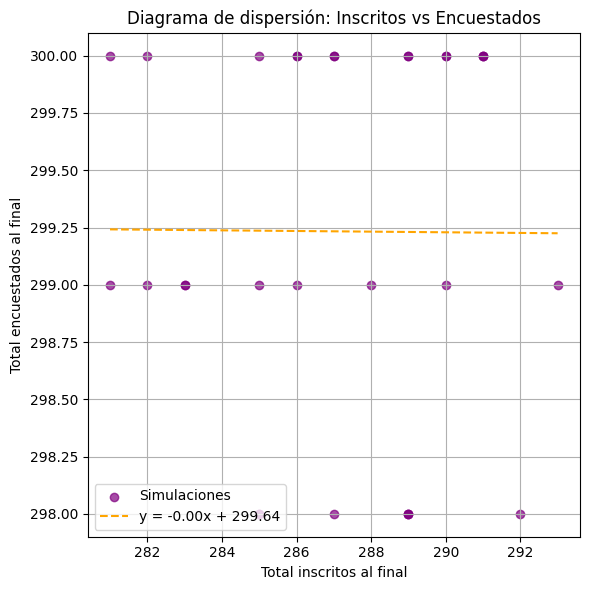


== RESULTADOS FINALES ==
Inscripciones - Media: 287.07, Desv. Est.: 3.32, Error % medio: 0.98%
Encuestas     - Media: 299.23, Desv. Est.: 0.80, Error % medio: 0.24%

📌 Última simulación:
- Inscritos totales:  290
- Encuestas totales:  300


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- PARÁMETROS GENERALES ----------
N_PERSONAS = 300  # Número total de personas simuladas
ESTADOS = ['E', 'Ne', 'N', 'Ni', 'I']  # Estados actitudinales posibles

# Probabilidades de inscripción y de respuesta a la encuesta según el estado
PROB_X_ESTADO = {
    'E':  (0.90, 0.95),  # Muy entusiasta
    'Ne': (0.70, 0.80),  # Neutral-entusiasta
    'N': (0.70, 0.80),  # Neutral-entusiasta
    'Ni': (0.45, 0.60),  # Neutral-indiferente
    'I':  (0.10, 0.25)   # Indiferente
}

# ---------- FUNCIONES PRINCIPALES ----------

# Simula el comportamiento de inscripción y respuesta a encuestas durante 'n_semanas'
def simulacion(n_semanas: int):
    estados = np.random.choice(ESTADOS, size=N_PERSONAS)  # Asignar estado actitudinal aleatoriamente
    inscrito = np.zeros(N_PERSONAS, dtype=bool)           # Estado de inscripción (False inicialmente)
    encuestado = np.zeros(N_PERSONAS, dtype=bool)         # Estado de encuesta (False inicialmente)

    acumulado_insc = []  # Lista para inscripciones acumuladas semana a semana
    acumulado_enc = []   # Lista para encuestas acumuladas semana a semana

    for _ in range(n_semanas):
        # Simular inscripciones
        pendientes_insc = ~inscrito
        if pendientes_insc.any():
            probs_insc = np.array([PROB_X_ESTADO[e][0] for e in estados])
            rand_vals = np.random.random(N_PERSONAS)
            nuevos = pendientes_insc & (rand_vals < probs_insc)
            inscrito[nuevos] = True

        # Simular encuestas
        pendientes_enc = ~encuestado
        if pendientes_enc.any():
            probs_enc = np.array([PROB_X_ESTADO[e][1] for e in estados])
            rand_vals = np.random.random(N_PERSONAS)
            nuevos = pendientes_enc & (rand_vals < probs_enc)
            encuestado[nuevos] = True

        # Guardar acumulados de la semana
        acumulado_insc.append(int(inscrito.sum()))
        acumulado_enc.append(int(encuestado.sum()))

        # Si ya todos están inscritos y encuestados, llenar lo que falta con los totales
        if inscrito.all() and encuestado.all():
            faltan = n_semanas - len(acumulado_insc)
            acumulado_insc.extend([N_PERSONAS]*faltan)
            acumulado_enc.extend([N_PERSONAS]*faltan)
            break

    return acumulado_insc, acumulado_enc

# Ejecuta múltiples simulaciones y guarda los resultados
def ejecutar_simulaciones(n_semanas: int, n_sim: int):
    resultados = []
    for _ in range(n_sim):
        insc, enc = simulacion(n_semanas)
        resultados.append({'inscritos': insc, 'encuestas': enc})
    return resultados

# ---------- VISUALIZACIONES ----------

# Graficar las curvas de inscripciones y encuestas (ojivas)
def graficar_ojivas(resultados, n_semanas):
    semanas = np.arange(1, n_semanas+1)

    # Inscripciones acumuladas
    plt.figure(figsize=(10,5))
    for i, r in enumerate(resultados, 1):
        plt.plot(semanas, r['inscritos'], marker='o', linewidth=2, label=f"Sim. {i}")
    plt.title("Inscripciones acumuladas por semana")
    plt.xlabel("Semana"); plt.ylabel("Inscritos")
    plt.ylim(0, N_PERSONAS+10); plt.grid(True); plt.legend(); plt.tight_layout()
    plt.show()

    # Encuestas acumuladas
    plt.figure(figsize=(10,5))
    for i, r in enumerate(resultados, 1):
        plt.plot(semanas, r['encuestas'], marker='s', linewidth=2, label=f"Sim. {i}")
    plt.title("Encuestas acumuladas por semana")
    plt.xlabel("Semana"); plt.ylabel("Encuestas completas")
    plt.ylim(0, N_PERSONAS+10); plt.grid(True); plt.legend(); plt.tight_layout()
    plt.show()

# Histograma de resultados finales (último valor)
def histograma_final(resultados, clave='inscritos'):
    finales = [r[clave][-1] for r in resultados]
    plt.figure(figsize=(7,4))
    plt.hist(finales, bins=10, edgecolor='black', alpha=0.7, color='skyblue')
    plt.axvline(np.mean(finales), color='red', ls='--',
                label=f"Media {np.mean(finales):.1f}")
    plt.title(f"Histograma total {clave}")
    plt.xlabel(f"{clave.capitalize()} al final"); plt.ylabel("Frecuencia")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
    return np.array(finales)

# ---------- DIAGRAMA DE DISPERSIÓN CON REGRESIÓN ----------

def graficar_dispersion(inscritos_finales, encuestas_finales):
    plt.figure(figsize=(6,6))
    plt.scatter(inscritos_finales, encuestas_finales, color='purple', alpha=0.7, label="Simulaciones")

    # Calcular línea de regresión
    m, b = np.polyfit(inscritos_finales, encuestas_finales, 1)
    x_vals = np.array([min(inscritos_finales), max(inscritos_finales)])
    y_vals = m * x_vals + b
    plt.plot(x_vals, y_vals, color='orange', linestyle='--', label=f"y = {m:.2f}x + {b:.2f}")

    plt.title("Diagrama de dispersión: Inscritos vs Encuestados")
    plt.xlabel("Total inscritos al final")
    plt.ylabel("Total encuestados al final")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ---------- MÉTRICAS ----------

# Calcula media, desviación estándar y error porcentual medio
def metricas(finales):
    media = finales.mean()
    std   = finales.std(ddof=0)
    err   = np.abs((finales - media)/media)*100
    return media, std, err.mean()

# ---------- EJECUCIÓN MANUAL ----------

# Inputs desde teclado
n_semanas = int(input("Ingrese el número de semanas (ej. 10): "))
n_simulaciones = int(input("Ingrese el número de simulaciones (ej. 5): "))

# Ejecutar simulaciones
resultados = ejecutar_simulaciones(n_semanas, n_simulaciones)

# Graficar ojivas
print("\n Ojivas")
graficar_ojivas(resultados, n_semanas)

# Histogramas y métricas
print("\n Histograma inscritos")
finales_insc = histograma_final(resultados, 'inscritos')
print("\n Histograma encuestas")
finales_enc  = histograma_final(resultados, 'encuestas')

# Diagrama de dispersión
print("\n Diagrama de dispersión")
graficar_dispersion(finales_insc, finales_enc)

# Métricas
m_i, s_i, e_i = metricas(finales_insc)
m_e, s_e, e_e = metricas(finales_enc)

# Mostrar métricas
print("\n== RESULTADOS FINALES ==")
print(f"Inscripciones - Media: {m_i:.2f}, Desv. Est.: {s_i:.2f}, Error % medio: {e_i:.2f}%")
print(f"Encuestas     - Media: {m_e:.2f}, Desv. Est.: {s_e:.2f}, Error % medio: {e_e:.2f}%")

# Última simulación
ult = resultados[-1]
print("\n📌 Última simulación:")
print(f"- Inscritos totales:  {ult['inscritos'][-1]}")
print(f"- Encuestas totales:  {ult['encuestas'][-1]}")
